In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('online_retail.csv')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
print("Rows and Columns:", df.shape)

Rows and Columns: (541909, 8)


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(5268)

In [32]:
(df['Quantity'] < 0).sum()

np.int64(0)

In [33]:
df = df[df['Quantity'] > 0]

In [13]:
(df['UnitPrice'] < 0).sum()

np.int64(2)

In [34]:
df = df[df['UnitPrice'] > 0]

In [35]:
(df['UnitPrice'] < 0).sum()

np.int64(0)

In [14]:
df['Country'].nunique()

38

In [15]:
df['Country'].unique()

<StringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Austria',
               'Israel',              'Finland',              'Bahrain',
               'Greece',            'Hong Kong',            'Singapore',
              'Lebanon', 'United Arab Emirates',         'Saudi Arabia',
       'Czech Republic',               'Canada',          'Unspecified',
               'Brazil',                  'USA',   'European Community',
                'Malta',                  'RSA']
Length: 38, dtype: str

In [19]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [25]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Invoicedate'],
      dtype='str')

In [26]:
df.drop('Invoicedate', axis=1, inplace=True)

In [27]:
df.info()

<class 'pandas.DataFrame'>
Index: 535187 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    535187 non-null  str           
 1   StockCode    535187 non-null  str           
 2   Description  535187 non-null  str           
 3   Quantity     535187 non-null  int64         
 4   InvoiceDate  535187 non-null  datetime64[us]
 5   UnitPrice    535187 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      535187 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 36.7 MB


In [21]:
df = df.drop_duplicates()

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df = df.dropna(subset=['Description'])

In [82]:
missing_customer = df['CustomerID'].isnull().sum()
print("Missing CustomerID:", missing_customer)

Missing CustomerID: 132186


In [36]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
dtype: int64


In [37]:
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
0


In [40]:
print("\nNegative Quantities:")
print((df['Quantity'] < 0).sum())


Negative Quantities:
0


In [41]:
print("\nNegative Prices:")
print((df['UnitPrice'] < 0).sum())


Negative Prices:
0


In [42]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,524878.000000,524878,524878.000000,392692.000000
mean,10.616600,2011-07-04 15:30:16.317049,3.922573,15287.843865
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,1.000000,2011-03-28 12:13:00,1.250000,13955.000000
50%,4.000000,2011-07-20 11:22:00,2.080000,15150.000000
75%,11.000000,2011-10-19 11:41:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000
std,156.280031,NaN,36.093028,1713.539549


In [44]:
df.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,524878,524878,524878,524878.000000,524878,524878.000000,392692.000000,524878
unique,19960,3922,4026,NaN,NaN,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114,2253,2311,NaN,NaN,NaN,NaN,479985
mean,NaN,NaN,NaN,10.616600,2011-07-04 15:30:16.317049,3.922573,15287.843865,NaN
min,NaN,NaN,NaN,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 12:13:00,1.250000,13955.000000,NaN
50%,NaN,NaN,NaN,4.000000,2011-07-20 11:22:00,2.080000,15150.000000,NaN
75%,NaN,NaN,NaN,11.000000,2011-10-19 11:41:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000,NaN


In [45]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [46]:
df[['Quantity', 'UnitPrice', 'Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


KPI Metrics

In [49]:
total_revenue = df['Revenue'].sum()
print("total Revenue:", total_revenue)

total Revenue: 10642110.804000001


In [51]:
total_orders = df['InvoiceNo'].nunique()
print("total Orders:", total_orders)

total Orders: 19960


In [52]:
total_products = df['StockCode'].nunique()
print("total Products:", total_products)

total Products: 3922


In [55]:
total_countries = df['Country'].nunique()
print("total Countries:", total_countries)

total Countries: 38


In [54]:
df['Revenue'].describe()

count    524878.000000
mean         20.275399
std         271.693566
min           0.001000
25%           3.900000
50%           9.920000
75%          17.700000
max      168469.600000
Name: Revenue, dtype: float64

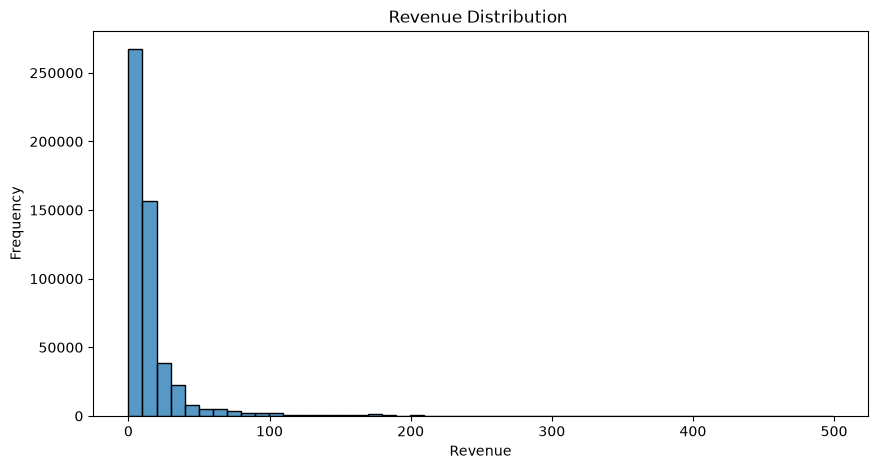

In [64]:
plt.figure(figsize=(10,5))

sns.histplot(df[df['Revenue'] < 500]['Revenue'], bins=50)

plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency')

plt.show()           

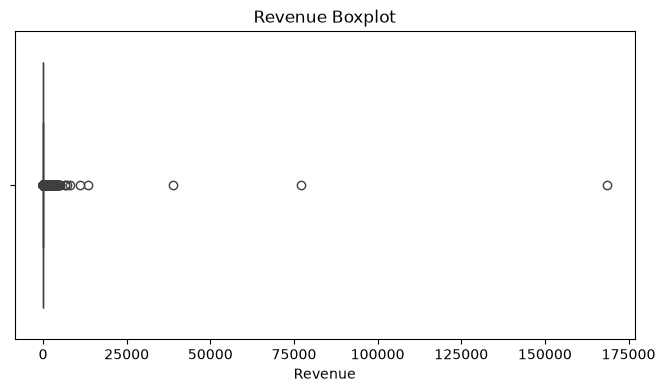

In [58]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['Revenue'])

plt.title('Revenue Boxplot')

plt.show()

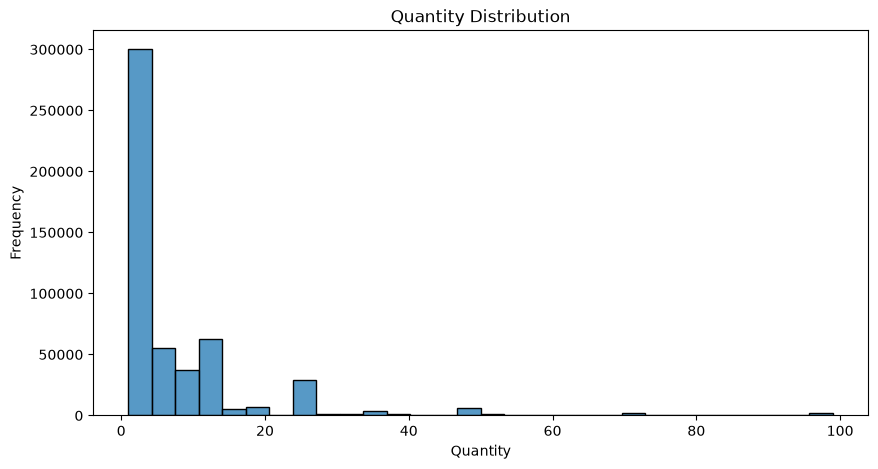

In [62]:
plt.figure(figsize=(10,5))

sns.histplot(df[df['Quantity'] < 100]['Quantity'], bins=30)

plt.title('Quantity Distribution')
plt.xlabel('Quantity')
plt.ylabel('Frequency')

plt.show()

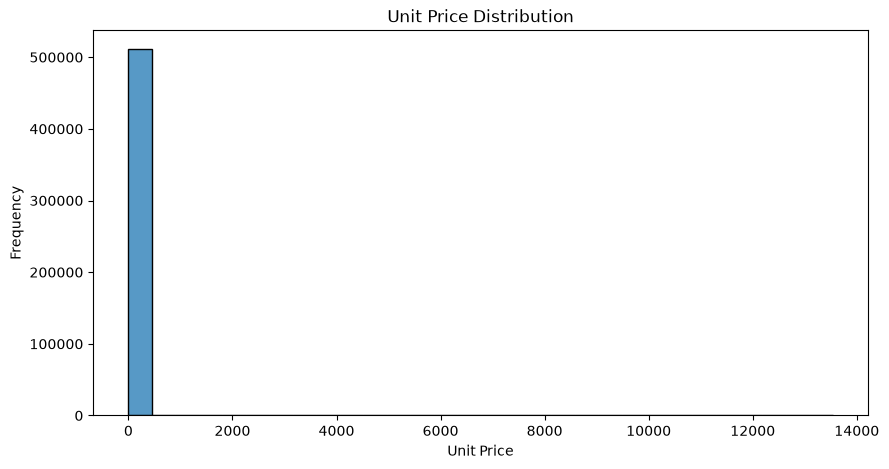

In [63]:
plt.figure(figsize=(10,5))

sns.histplot(df[df['Quantity'] < 50]['UnitPrice'], bins=30)

plt.title('Unit Price Distribution')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')

plt.show()

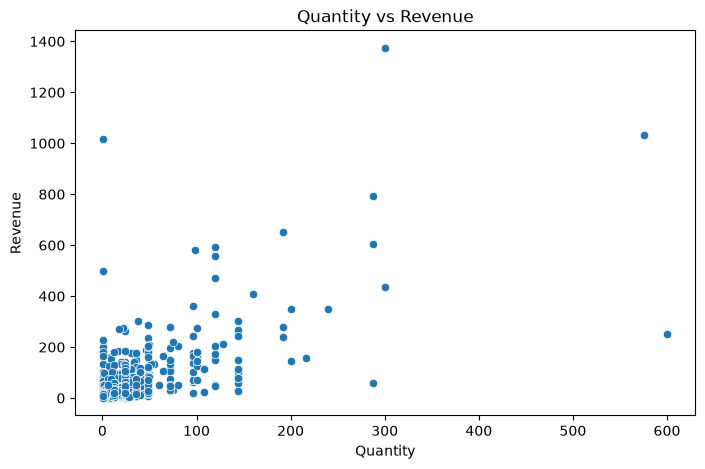

In [66]:
plt.figure(figsize=(8,5))

sample_df = df.sample(5000)

sns.scatterplot( x='Quantity', y='Revenue', data=sample_df)

plt.title('Quantity vs Revenue')
plt.xlabel('Quantity')
plt.ylabel('Revenue')

plt.show()

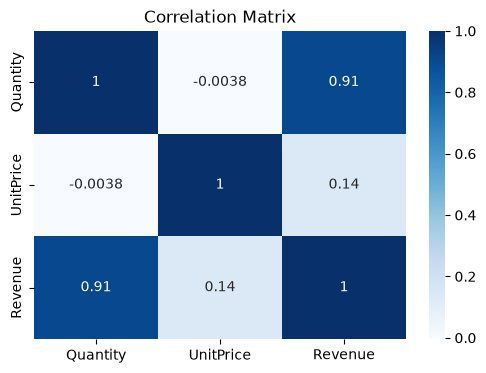

In [67]:
corr = df[['Quantity', 'UnitPrice', 'Revenue']].corr()

plt.figure(figsize=(6,4))

sns.heatmap(corr, annot=True, cmap='Blues')

plt.title('Correlation Matrix')

plt.show()

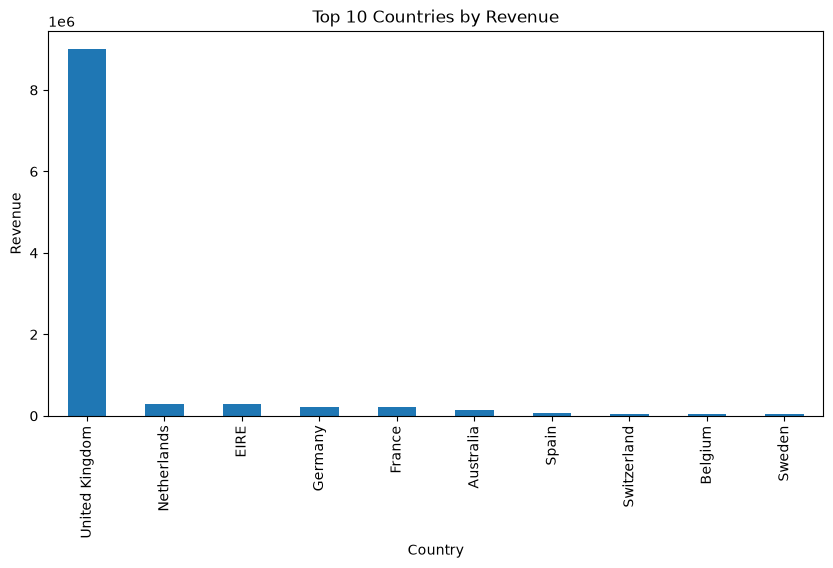

In [80]:
country_revenue = df.groupby('Country')['Revenue'].sum()
country_revenue = country_revenue.sort_values(ascending=False)
country_revenue = country_revenue.head(10)

plt.figure(figsize=(10,5))

country_revenue.plot(kind='bar')

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')


plt.show()

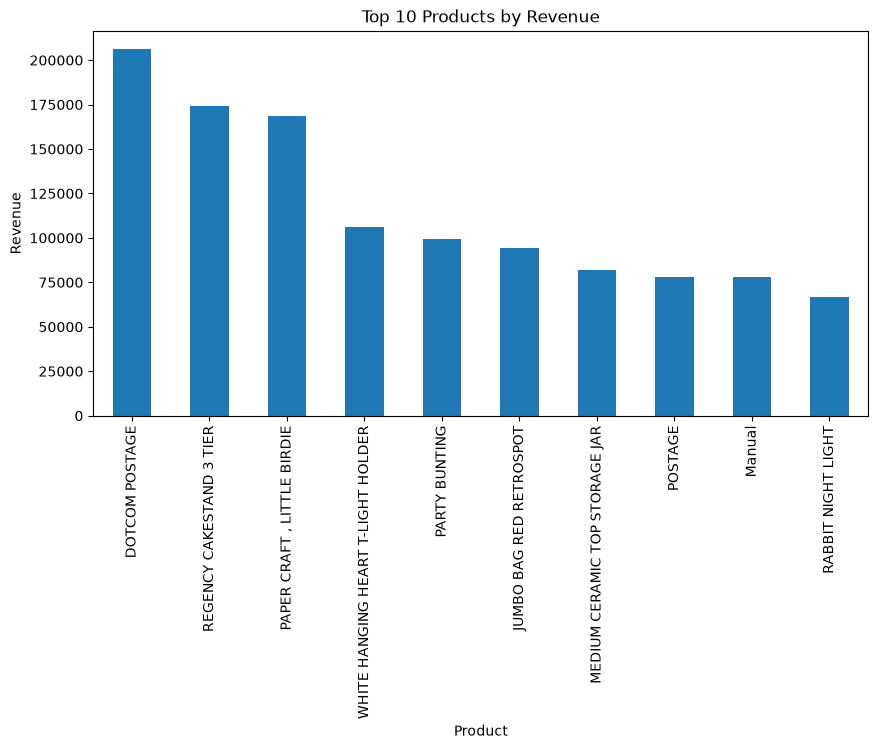

In [81]:
product_revenue = df.groupby('Description')['Revenue'].sum()
product_revenue = product_revenue.sort_values(ascending=False)
product_revenue = product_revenue.head(10)

plt.figure(figsize=(10,5))

product_revenue.plot(kind='bar')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')

plt.show()

In [73]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

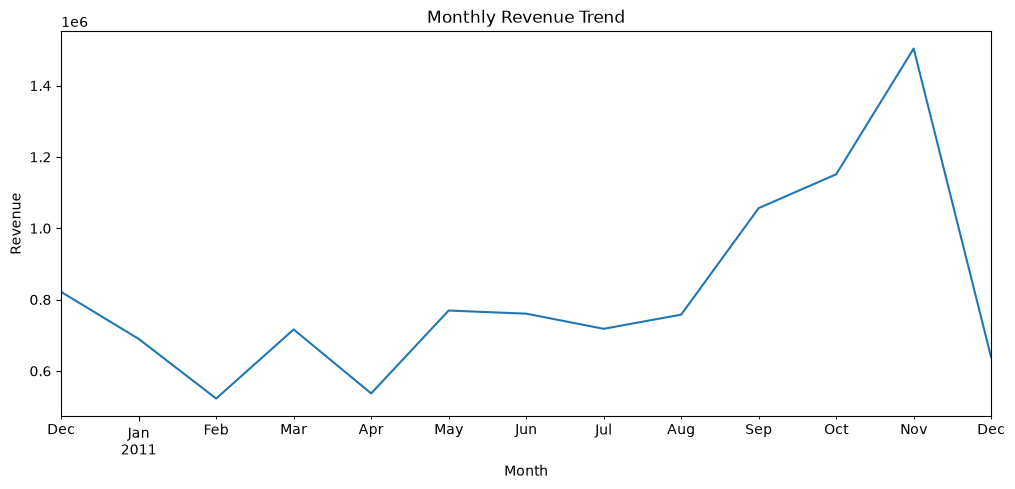

In [74]:
monthly_revenue = df.groupby('Month')['Revenue'].sum()

plt.figure(figsize=(12,5))

monthly_revenue.plot()

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

In [84]:
df.to_csv('cleaned_online_retail.csv', index=False)

In [85]:
import os

print(os.getcwd())

C:\Users\devya\Documents


In [86]:
df.shape

(524878, 10)